In [7]:
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.nn import functional as F
import torch
import pandas as pd
#import wfdb
from scipy.stats import pearsonr
#from SoftDTW_functions import SoftDTW
#from tqdm import tqdm
import multiprocessing as mp
from matplotlib.cm import get_cmap
import neurokit2 as nk
import ast


from multiprocessing import Pool, cpu_count
from functools import partial

#from Load_Data import load_ptb_xl_data
from VQ_VAE import Encoder_net, Quantize_net, Decoder_net
from NanoGPT import GPTLanguageModel

In [67]:
def decode_embed(emb_ind, codebook):
    # Pas de .numpy() : on reste en tenseurs PyTorch
    if isinstance(emb_ind, torch.Tensor):
        emb_ind = emb_ind.detach().cpu()
    codebook = codebook.detach().cpu()
    
    new_out = []
    for i in range(len(emb_ind)):
        indices = emb_ind[i].long()
        # Sélection vectorisée des vecteurs du codebook
        vectors = codebook[:, indices]  # shape: (encoding_size, seq_len)
        new_out.append(vectors)
    
    return torch.stack(new_out)  # shape: (batch, encoding_size, seq_len)


def decode_embed_torch(indices, codebook):
    """
    indices: (B, T)
    codebook: (K, D)
    retourne: (B, D, T)
    """
    # indices -> (B, T, D)
    embeddings = codebook[indices.long()]

    # transpose pour correspondre au decoder
    return embeddings.permute(0, 2, 1)

def generate_ecg(encoder, decoder, quantizer, NanoGPT, nb_ecg, device, ecg, block_size=77):
    print("Generating ECGs...", str(block_size))
    batch_size = 256
    
    generate_ecgs = []
    for i in range(nb_ecg):
        if len(ecg) < batch_size:
            inp = ecg
            with torch.no_grad():
                block_size = 77
                inp = torch.tensor(inp, dtype=torch.float32).to(device)
                encoded = encoder(inp)
                quantized, _, embed_ind, codebook = quantizer(encoded.transpose(1, 2))
                generated = NanoGPT.generate(embed_ind[:,:block_size], max_new_tokens=306)
                generated = generated.detach().cpu()
                ind_generated = generated
                generated = decode_embed(generated, codebook.detach().cpu())
                generated = decoder(generated)
                generated = generated.detach().cpu()
            generate_ecgs.append(generated)
        else:
            for b in range(0, len(ecg), batch_size):
                inp = ecg[b:b+batch_size]
                with torch.no_grad():
                    inp = torch.tensor(inp, dtype=torch.float32).to(device)
                    encoded = encoder(inp)
                    quantized, _, embed_ind, codebook = quantizer(encoded.transpose(1, 2))
                    generated = NanoGPT.generate(embed_ind[:,:block_size], max_new_tokens=306)
                    generated = generated.detach().cpu()
                    ind_generated = generated
                    generated = decode_embed(generated, codebook.detach().cpu())
                    generated = decoder(generated)
                    generated = generated.detach().cpu()
                generate_ecgs.append(generated)
    return generate_ecgs

In [68]:
# path = "../Data/"
# train_data, test_data, val_data, train_id, test_id, val_id, train_leads, test_leads, val_leads = load_ptb_xl_data(path)

vocab_size = 64

# Device dynamique
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Initialisation des modèles ---
encoder = Encoder_net(4)

# Initialisation propre du encoder pour récupérer la taille
with torch.no_grad():
    temp = torch.randn(1, 1, 5000)
    temp = encoder(temp)
    encoding_size = temp.shape[1]

decoder = Decoder_net(4 - 1, chanel_in=encoding_size)
quantizer = Quantize_net(encoding_size, vocab_size)

NanoGPT = GPTLanguageModel(
    block_size=306,
    vocab_size=vocab_size,
    n_embd=384,
    n_layer=10,
    n_head=10,
    dropout=0.2,
    num_classes=12,
    device=device
)

# --- Fonction utilitaire pour charger proprement ---
def load_model(model, path, device):
    state_dict = torch.load(path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model

# --- Chemins ---
encoder_path = f"../Models/VQ-VAE/Encoder_vocab_size_{vocab_size}_4_epoch0.pth"
decoder_path = f"../Models/VQ-VAE/Decoder_vocab_size_{vocab_size}_4_epoch0.pth"
quantizer_path = f"../Models/VQ-VAE/Quantizer_vocab_size_{vocab_size}_4_epoch0.pth"
gpt_path = f"../Models/NanoGPT/Transformer_{vocab_size}_10.pth"

# --- Chargement ---
encoder = load_model(encoder, encoder_path, device)
decoder = load_model(decoder, decoder_path, device)
quantizer = load_model(quantizer, quantizer_path, device)
NanoGPT = load_model(NanoGPT, gpt_path, device)

Using device: cpu


In [69]:
subset = np.load("../Data/Dataset/subset.npy", allow_pickle=True)

In [70]:
print(subset.shape)

(100, 1, 5000)


In [71]:
generated_ecgs = generate_ecg(encoder, decoder, quantizer, NanoGPT, nb_ecg=10, device=device, ecg=torch.tensor(subset[:2]).to(device), block_size=77)

Generating ECGs... 77


/var/folders/75/9_18d4ls35l3sdydtwpwfh600000gn/T/ipykernel_51752/3053312025.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inp = torch.tensor(inp, dtype=torch.float32).to(device)


In [72]:
print("Generated ECGs shape:", [gen.shape for gen in generated_ecgs])

Generated ECGs shape: [torch.Size([2, 1, 5000]), torch.Size([2, 1, 5000]), torch.Size([2, 1, 5000]), torch.Size([2, 1, 5000]), torch.Size([2, 1, 5000]), torch.Size([2, 1, 5000]), torch.Size([2, 1, 5000]), torch.Size([2, 1, 5000]), torch.Size([2, 1, 5000]), torch.Size([2, 1, 5000])]


Generated ECGs converted to numpy.
First generated ECG shape: torch.Size([2, 1, 5000])


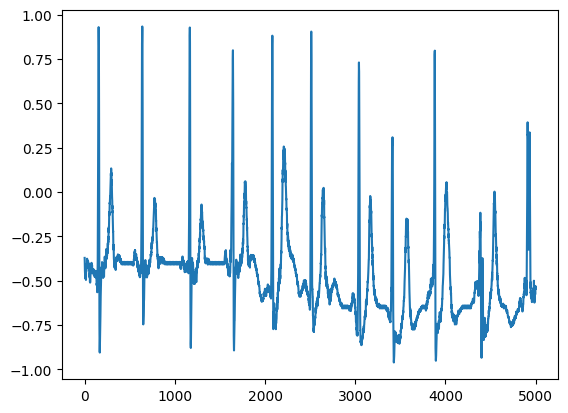

In [79]:
generate_ecgs = [gen.cpu().detach() for gen in generated_ecgs]
print("Generated ECGs converted to numpy.")
print("First generated ECG shape:", generate_ecgs[0].shape)
plt.plot(generate_ecgs[0][0][0].tolist())  # .tolist() au lieu de numpy